In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
import pandas as pd
import pickle
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
import warnings
from IPython.display import display

pd.set_option('display.max_colwidth', None)  
pd.set_option('display.precision', 2)
pd.set_option("display.max_columns", None) 

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [10]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)

df = (pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
    .rename(columns={
            'FECHA_NACIMIENTO':'FECHA_NAC',
            'FECHA_INGRESO':'FECHA_ING',
            'FECHA_EGRESO': 'FECHA_EGR',
            #'COMUNA': 'COMUNA_N',
        })
    .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))')
)

In [11]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Definir los Z-scores para los percentiles proporcionados
z_scores_provided = stats.norm.ppf([2.5/100, 5/100, 10/100, 25/100, 50/100, 75/100, 90/100, 95/100, 97.5/100])
# percentiles_to_find = [0.001, 0.01, 0.1, 0.5, 1, 99, 99.5, 99.9, 99.99, 99.999]
percentiles_to_find = [0.0001 ,0.001, 0.01, 0.1, 0.5, 1, 99, 99.5, 99.9, 99.99, 99.999, 99.9999]
def calculate_percentiles_dist_normal(row):
    values = row[['p_025', 'p_05', 'p_10', 'p_25', 'p_50', 'p_75', 'p_90', 'p_95', 'p_975']]
    slope, intercept = stats.linregress(z_scores_provided, values)[:2]
    z_scores_to_find = stats.norm.ppf([p/100 for p in percentiles_to_find])
    
    # Calculate slope_list assuming middle value for the reference
    middle_index = len(values) // 2
    slope_list = (values - values[middle_index]) / z_scores_provided
    return  pd.Series(
                np.concatenate([
                    slope * z_scores_to_find + intercept,  # Percentiles
                    [intercept],  # Mean of regression
                    [slope],  # Slope of regression
                    slope_list  # Slope list
                ]), 
                index=[
                    'p_000001','p_00001','p_0001','p_001','p_005', 'p_01', 'p_99', 'p_995','p_999','p_9999','p_99999','p_999999','media_reg', 'desviacion_estandar_reg'
                ] + [f'slope_{i}' for i in range(len(values))]
    )
    
def calculate_percentiles_dist_lognormal(row):
    # Percentiles proporcionados y valores correspondientes
    percentiles_provided = [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5]
    values = row[['p_025', 'p_05', 'p_10', 'p_25', 'p_50', 'p_75', 'p_90', 'p_95', 'p_975']].values
    
    # Transformar percentiles a z-scores
    z_scores_provided = stats.norm.ppf([p / 100 for p in percentiles_provided])
    
    # Transformar valores a la escala logarítmica
    log_values = np.log(values)
    
    # Ajustar una recta a los logaritmos de los valores
    slope, intercept, r_value, p_value, std_er = stats.linregress(z_scores_provided, log_values)
    
    # Estimar parámetros de la distribución lognormal
    mu = intercept
    sigma = slope
    
    # Percentiles que deseamos calcular
    # percentiles_to_find = [1, 99, 0.05, 99.5]
    z_scores_to_find = stats.norm.ppf([p / 100 for p in percentiles_to_find])
    
    # Calcular los valores correspondientes a los percentiles deseados en la escala lognormal
    calculated_values = stats.lognorm.ppf([p / 100 for p in percentiles_to_find], s=sigma, scale=np.exp(mu))
    
    # Calcular slope_list usando el valor medio como referencia
    middle_index = len(log_values) // 2
    slope_list = (log_values - log_values[middle_index]) / z_scores_provided
    
    # Retornar los percentiles calculados, media, desviación estándar y slope_list en un DataFrame
    return pd.Series(
        np.concatenate([
            calculated_values,   # Percentiles calculados
            [mu],                # Media (en escala logarítmica)
            [sigma],             # Desviación estándar (en escala logarítmica)
            slope_list           # Slope list
        ]), 
        index=
            [item+'_lognormal' for item in ['p_000001','p_00001','p_0001','p_001','p_005', 'p_01', 'p_99', 'p_995','p_999','p_9999','p_99999','p_999999','media_reg', 'desviacion_estandar_reg'] ]
            #+ ['mu_reg_lognormal', 'sigma_reg_lognormal']               # Media y desviación estándar en escala logarítmica
            + [f'slope_lognormal_{i}' for i in range(len(slope_list))]  # Slope list
    )

# Ejemplo de uso con DataFrame
    
# Procesamiento en una línea
df_oms = (
    pd.read_csv(path_data/"curva_estandar_OMS.csv")
    .assign(SEMANAS=np.arange(14, 41))

    .pipe(lambda df:df.join( df.apply(calculate_percentiles_dist_normal, axis=1)))
    .pipe(lambda df:df.join( df.apply(calculate_percentiles_dist_lognormal, axis=1)))
)

df_oms.head()

,p_025,p_05,p_10,p_25,p_50,p_75,p_90,p_95,p_975,SEMANAS,p_000001,p_00001,p_0001,p_001,p_005,p_01,p_99,p_995,p_999,p_9999,p_99999,p_999999,media_reg,desviacion_estandar_reg,slope_0,slope_1,slope_2,slope_3,slope_4,slope_5,slope_6,slope_7,slope_8,p_000001_lognormal,p_00001_lognormal,p_0001_lognormal,p_001_lognormal,p_005_lognormal,p_01_lognormal,p_99_lognormal,p_995_lognormal,p_999_lognormal,p_9999_lognormal,p_99999_lognormal,p_999999_lognormal,media_reg_lognormal,desviacion_estandar_reg_lognormal,slope_lognormal_0,slope_lognormal_1,slope_lognormal_2,slope_lognormal_3,slope_lognormal_4,slope_lognormal_5,slope_lognormal_6,slope_lognormal_7,slope_lognormal_8
0,70,73,78,83,90,98,104,109,113,14,39.49,44.78,50.68,57.48,63.04,65.74,116.04,118.74,124.30,131.10,137.00,142.28,90.89,10.81,10.20,10.34,9.36,10.38,NaN,11.86,10.92,11.55,11.73,50.62,53.68,57.32,61.82,65.77,67.77,118.57,122.18,129.98,140.19,149.70,158.76,4.50,0.12,0.13,0.13,0.11,0.12,NaN,0.13,0.11,0.12,0.12
1,89,93,99,106,114,124,132,138,144,15,50.49,57.16,64.62,73.22,80.25,83.65,147.23,150.64,157.67,166.26,173.72,180.40,115.44,13.66,12.76,12.77,11.70,11.86,NaN,14.83,14.05,14.59,15.31,64.51,68.39,73.01,78.71,83.70,86.23,150.39,154.94,164.77,177.63,189.61,201.01,4.74,0.12,0.13,0.12,0.11,0.11,NaN,0.12,0.11,0.12,0.12
2,113,117,124,133,144,155,166,174,181,16,63.92,72.28,81.61,92.37,101.17,105.43,185.01,189.28,198.08,208.83,218.17,226.52,145.22,17.10,15.82,16.41,15.61,16.31,NaN,16.31,17.17,18.24,18.88,81.47,86.34,92.12,99.26,105.52,108.69,188.87,194.55,206.81,222.84,237.77,251.97,4.96,0.12,0.12,0.13,0.12,0.12,NaN,0.11,0.11,0.12,0.12
3,141,146,155,166,179,193,207,217,225,17,80.29,90.64,102.21,115.53,126.43,131.71,230.29,235.57,246.47,259.79,271.36,281.71,181.00,21.19,19.39,20.06,18.73,19.27,NaN,20.76,21.85,23.10,23.47,101.92,107.97,115.16,124.03,131.79,135.73,235.03,242.05,257.20,277.01,295.44,312.97,5.19,0.12,0.12,0.12,0.11,0.11,NaN,0.11,0.11,0.12,0.12
4,174,181,192,206,222,239,255,268,278,18,100.18,112.90,127.10,143.47,156.85,163.35,284.43,290.92,304.31,320.68,334.88,347.60,223.89,26.02,24.49,24.93,23.41,23.72,NaN,25.20,25.75,27.97,28.57,126.53,133.99,142.85,153.78,163.35,168.20,290.28,298.90,317.49,341.79,364.39,385.88,5.40,0.12,0.12,0.12,0.11,0.11,NaN,0.11,0.11,0.11,0.11


Predicciones para las semanas 41 y 42:
    p_00001   p_0001    p_001    p_005     p_01     p_99    p_995    p_999  \
41  1929.44  2189.75  2489.60  2734.91  2853.88  5072.65  5191.62  5436.93   
42  2061.23  2340.44  2662.05  2925.16  3052.77  5432.56  5560.17  5823.28   

     p_9999  p_99999  
41  5736.78   5997.1  
42  6144.89   6424.1  


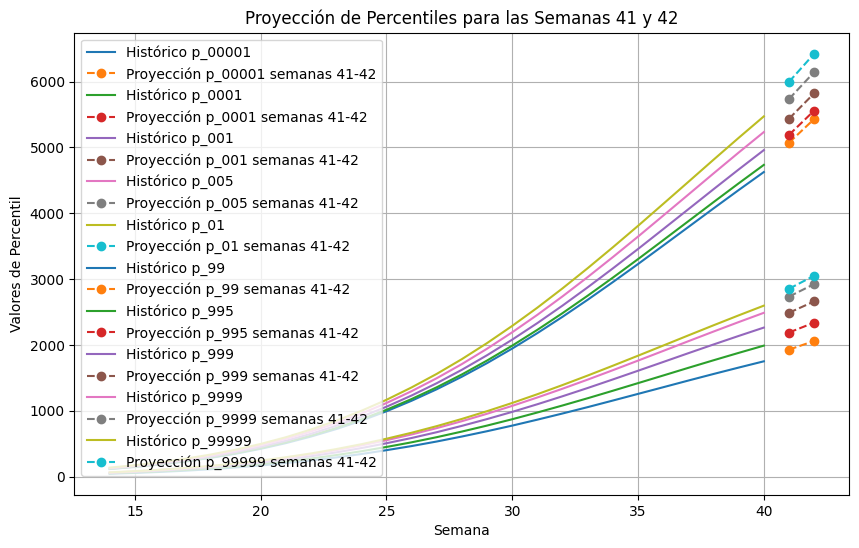

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
percentiles = ['p_00001', 'p_0001', 'p_001', 'p_005', 'p_01', 'p_99', 'p_995', 'p_999', 'p_9999', 'p_99999']

for percentil in percentiles:
    # Ajustar un polinomio de grado 2 a los datos
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    
    # Crear una función polinómica a partir de los coeficientes
    poly_func = np.poly1d(coefs)
    
    # Hacer predicciones para las semanas 41 y 42
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir las predicciones a un DataFrame para mayor claridad
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

print("Predicciones para las semanas 41 y 42:")
print(predicciones_df)

# Opcional: visualizar la proyección
plt.figure(figsize=(10, 6))
for percentil in percentiles:
    plt.plot(semanas, df_oms[percentil], label=f'Histórico {percentil}')
    plt.plot(pred_semanas, predicciones_df[percentil], 'o--', label=f'Proyección {percentil} semanas 41-42')

plt.xlabel('Semana')
plt.ylabel('Valores de Percentil')
plt.title('Proyección de Percentiles para las Semanas 41 y 42')
plt.legend()
plt.grid(True)
plt.show()


Projections for weeks 41 to 45:
    p_00001_lognormal  p_99999_lognormal
41            2322.53            6573.26
42            2483.37            7043.87


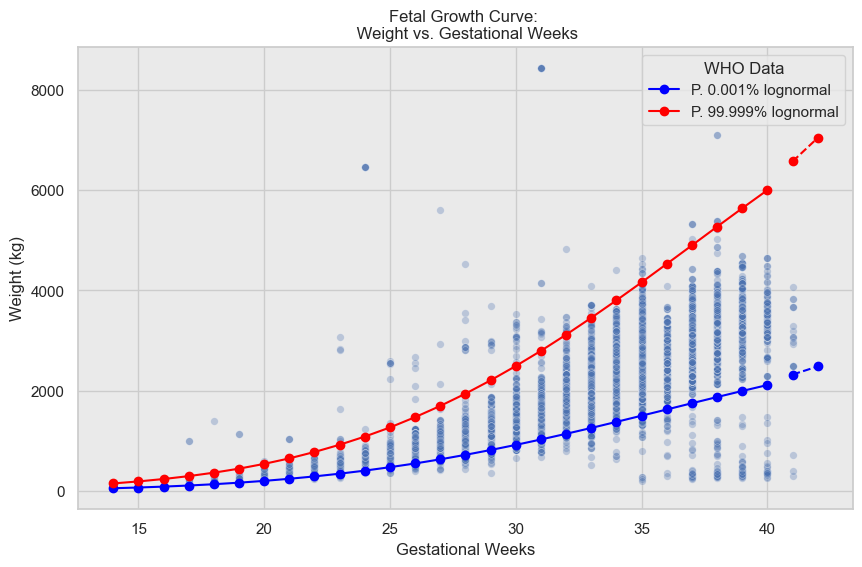

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista de los percentiles a proyectar
percentiles = ['p_00001_lognormal', 'p_99999_lognormal']

# Diccionario para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
for percentil in percentiles:
    # Ajustar un polinomio de grado 2 a los datos
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    
    # Crear una función polinómica a partir de los coeficientes
    poly_func = np.poly1d(coefs)
    
    # Hacer predicciones para las semanas 41-45
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir las predicciones a un DataFrame para mayor claridad
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

print("Projections for weeks 41 to 45:")
print(predicciones_df)
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})
# Visualizar las proyecciones y datos históricos
plt.figure(figsize=(10, 6))

# Graficar datos históricos y proyecciones para cada percentil
plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_00001_lognormal'], 
    color='blue', 
    linestyle='-',
    marker='o', 
    label='P. 0.001% lognormal'
)
plt.plot(
    pred_semanas, 
    predicciones_df['p_00001_lognormal'], 
    color='blue', 
    linestyle='--', 
    marker='o'
)

plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_99999_lognormal'], 
    color='red', 
    linestyle='-', 
    marker='o', 
    label='P. 99.999% lognormal'
)
plt.plot(
    pred_semanas, 
    predicciones_df['p_99999_lognormal'], 
    color='red', 
    linestyle='--', 
    marker='o'
)
sns.scatterplot(x='SEMANAS', y='PESO', data=df
                ,s=30,  # Tamaño más pequeño
                alpha=0.3,  # Mayor transparencia
                )
                

# Configuración de etiquetas y estilo del gráfico
plt.title('Fetal Growth Curve: \n Weight vs. Gestational Weeks')
plt.xlabel('Gestational Weeks')
plt.ylabel('Weight (kg)')
plt.legend(title='WHO Data')
plt.grid(True)
plt.show()
# fig.savefig("/Users/ignasi/Documents/ISCI/Projects/nirsevimab/Image/OMS_weight.png", dpi=400)  # 400 dpi para alta resolución
# fig.savefig("/Users/ignasi/Documents/ISCI/Projects/nirsevimab/Image/OMS_weight.eps", format="eps")  # EPS vectorial


In [14]:
(pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
 .dropna(subset=['PESO','SEMANAS'])
 .assign(fecha_nac = lambda x: pd.to_datetime(x['FECHA_NACIMIENTO'], format='%d%b%Y'),
              fechaIng_any = lambda x: pd.to_datetime(x['FECHA_INGRESO'], format='%d%b%Y'),
              ingreso_mayor_1_mes = lambda x: x.fecha_nac + pd.DateOffset(months=1) <= x.fechaIng_any )
 .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))')
 .query('ingreso_mayor_1_mes')
 .query('VIVO=="NO"')
 .groupby('DIAG1',as_index=False)
 .size()
 .sort_values('size',ascending=False)
# .assign(first_letter = lambda x: x.DIAG1[0])
#  .groupby('first_letter',as_index=False)
#  .agg('sum')
)['size'].sum()



135

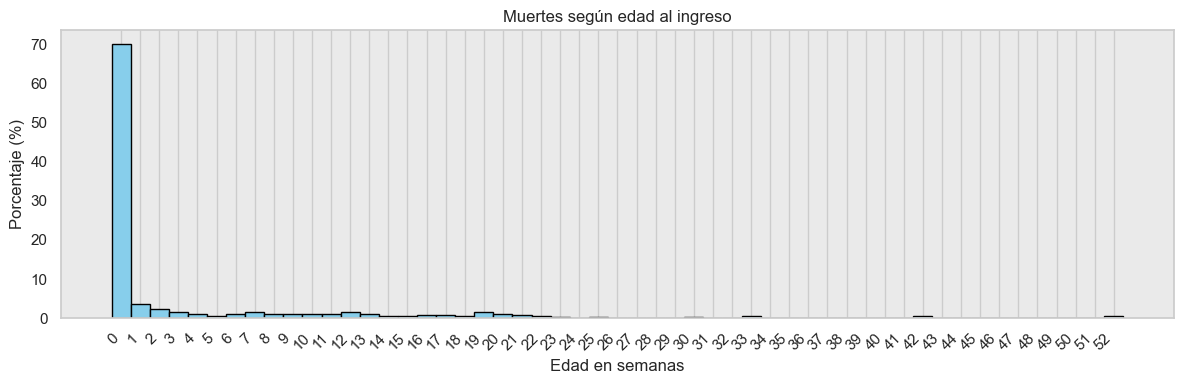

In [15]:
df_graf = (pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
 .dropna(subset=['PESO','SEMANAS'])
 .assign(fecha_nac = lambda x: pd.to_datetime(x['FECHA_NACIMIENTO'], format='%d%b%Y'),
              fechaIng_any = lambda x: pd.to_datetime(x['FECHA_INGRESO'], format='%d%b%Y'),
              ingreso_mayor_1_mes = lambda x:  (x.fechaIng_any - x.fecha_nac).dt.days)
 .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))')
 .query('VIVO=="NO"')
)

# Definir bins manualmente
# 1. Crear los intervalos de 7 días
max_dias = df_graf['ingreso_mayor_1_mes'].max()
bins = np.arange(0, max_dias + 7, 7)  # de 0 hasta max, saltos de 7

# 2. Histograma en proporciones (%)
counts, bin_edges = np.histogram(df_graf['ingreso_mayor_1_mes'], bins=bins)
proportions = counts / counts.sum() * 100

# 3. Graficar
plt.figure(figsize=(12, 4))
plt.bar(range(len(proportions)), proportions, width=1, color='skyblue', edgecolor='black')

# Etiquetas de eje x como rango de días (ej: 0–6, 7–13, ...)
labels = [f"{np.int32(bins[i]/7)}" for i in range(len(bins)-1)]
#[f"{np.int32(i/7)}" for i in range(len(bins)-1)]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')

plt.xlabel('Edad en semanas')
plt.ylabel('Porcentaje (%)')
plt.title('Muertes según edad al ingreso')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

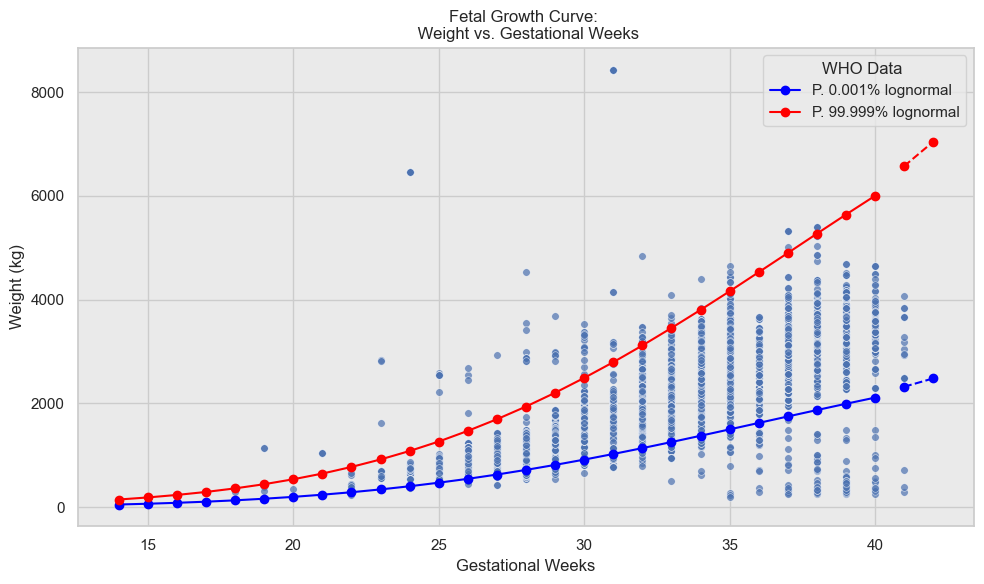

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista de los percentiles a proyectar
percentiles = ['p_00001_lognormal', 'p_99999_lognormal']

# Diccionario para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
for percentil in percentiles:
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    poly_func = np.poly1d(coefs)
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir las predicciones a un DataFrame
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

df = (pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
      .dropna(subset=['PESO','SEMANAS'])
    .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))')
    .query('VIVO=="SI"')
)

df['criterio'] = np.select(
    [
        df['RUN'].isin(lista_ruts_cardio),
        (df['PESO'] < 1500) & (df['SEMANAS'] > 35),
        (df['SEMANAS'] <= 35) & (df['PESO'] < 1500),
        (df['SEMANAS'] <= 35) & (df['PESO'] >= 1500)
        
    ],
    [
        'cardiopatía',
        '(error dato 1) bajo_peso_NO_prematuro',
        'bajo_peso_SI_prematuro',
        '(error dato 2) prematuro_No_bajo_peso'
    ],
    default='otro'
)
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})

# Visualización
plt.figure(figsize=(10, 6))

# Graficar datos históricos y proyecciones
plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_00001_lognormal'], 
    color='blue', linestyle='-', marker='o', 
    label='P. 0.001% lognormal'
)
plt.plot(
    pred_semanas, 
    predicciones_df['p_00001_lognormal'], 
    color='blue', linestyle='--', marker='o'
)
plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_99999_lognormal'], 
    color='red', linestyle='-', marker='o', 
    label='P. 99.999% lognormal'
)
plt.plot(
    pred_semanas, 
    predicciones_df['p_99999_lognormal'], 
    color='red', linestyle='--', marker='o'
)

# === NUEVO: Scatterplot con colores por criterio ===
sns.scatterplot(
    x='SEMANAS',
    y='PESO',
    data=df,
    s=30,
    alpha=0.7
)

# Estética del gráfico
plt.title('Fetal Growth Curve: \n Weight vs. Gestational Weeks')
plt.xlabel('Gestational Weeks')
plt.ylabel('Weight (kg)')
plt.legend(title='WHO Data ')
plt.grid(True)
plt.tight_layout()
plt.show()

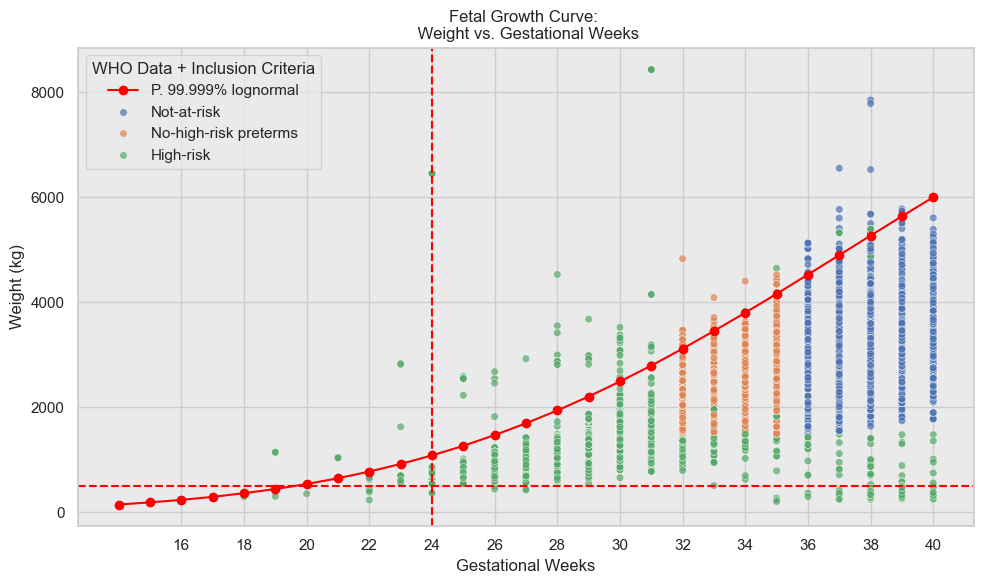

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista de los percentiles a proyectar
percentiles = ['p_00001_lognormal', 'p_99999_lognormal']

# Diccionario para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
for percentil in percentiles:
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    poly_func = np.poly1d(coefs)
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir las predicciones a un DataFrame
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

df = (pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
      .dropna(subset=['PESO','SEMANAS'])
    .query('VIVO=="SI"')
)

df['criterio'] = np.select(
    [
        (df['RUN'].isin(lista_ruts_cardio)) | (df['PESO'] < 1500) | (df['SEMANAS'] <32),
        (df['SEMANAS'] <= 35),
        
    ],
    [
        'High-risk',
        'No-high-risk preterms'
    ],
    default='Not-at-risk'
)

df = (pd.merge((
                df
                .dropna(subset=['SEMANAS'])  # Eliminar filas con NaN en 'SEMANAS'
                .assign(SEMANAS=lambda x: x['SEMANAS'].astype(int))  # Convertir 'SEMANAS' a int
                )
                , df_oms[['SEMANAS', 'p_00001', 'p_99999']],
                on='SEMANAS', 
                how='inner'
                )
      )


# Estilo del gráfico
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})

# Visualización
plt.figure(figsize=(10, 6))


# Línea horizontal azul en PESO = 501
plt.axhline(y=501, color='red', linestyle='--') #, label='PESO = 501 g'

# Línea vertical punteada negra en SEMANAS = 24
plt.axvline(x=24, color='red', linestyle='--') # label='SEMANAS = 24'

plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_99999_lognormal'], 
    color='red', linestyle='-', marker='o', 
    label='P. 99.999% lognormal'
)

# === NUEVO: Scatterplot con colores por criterio ===
sns.scatterplot(
    x='SEMANAS',
    y='PESO',
    data=df,
    hue='criterio',
    s=30,
    alpha=0.7
)

plt.xticks(np.arange(df['SEMANAS'].min(), df['SEMANAS'].max()+1, 2))
# Estética del gráfico
plt.title('Fetal Growth Curve: \n Weight vs. Gestational Weeks')
plt.xlabel('Gestational Weeks')
plt.ylabel('Weight (kg)')
plt.legend(title='WHO Data + Inclusion Criteria')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
df.query('criterio!="Not-at-risk"').RUN.nunique()

9611

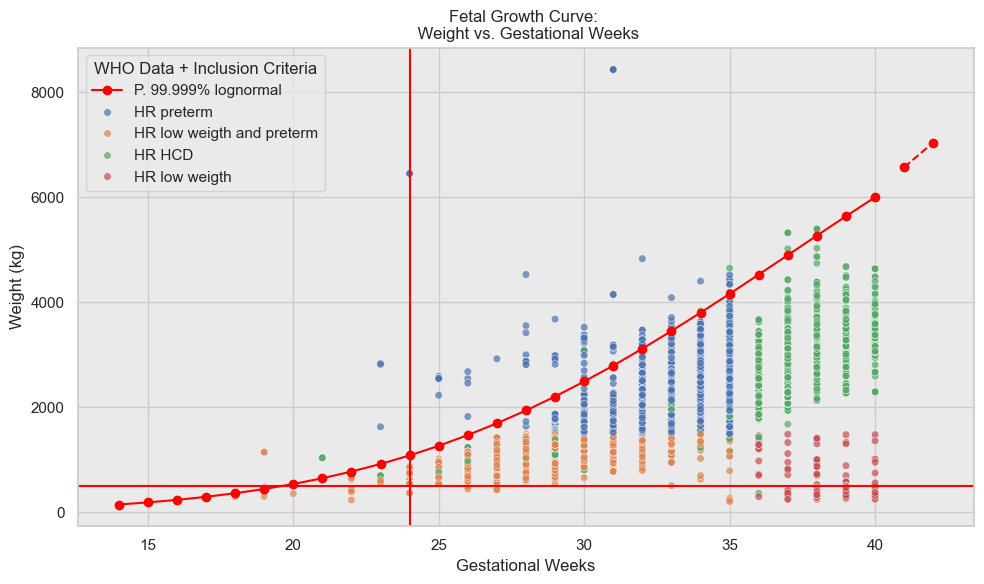

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista de los percentiles a proyectar
percentiles = ['p_00001_lognormal', 'p_99999_lognormal']

# Diccionario para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
for percentil in percentiles:
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    poly_func = np.poly1d(coefs)
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir las predicciones a un DataFrame
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

df = (pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv', encoding = "latin-1", sep = ";")
      .dropna(subset=['PESO','SEMANAS'])
    #  .query('PESO>=500')
    .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))') #
    .query('VIVO=="SI"')
)

df['criterio'] = np.select(
    [
        df['RUN'].isin(lista_ruts_cardio),
        (df['PESO'] < 1500) & (df['SEMANAS'] > 35),
        (df['SEMANAS'] <= 35) & (df['PESO'] < 1500),
        (df['SEMANAS'] <= 35) & (df['PESO'] >= 1500)
        
    ],
    [
        'HR HCD',
        'HR low weigth',
        'HR low weigth and preterm',
        'HR preterm'
    ],
    default='otro'
)

df = (pd.merge((
                df
                .dropna(subset=['SEMANAS'])  # Eliminar filas con NaN en 'SEMANAS'
                .assign(SEMANAS=lambda x: x['SEMANAS'].astype(int))  # Convertir 'SEMANAS' a int
                )
                , df_oms[['SEMANAS', 'p_00001', 'p_99999']],
                on='SEMANAS', 
                how='inner'
                )
      )
# df.loc[(df['PESO'] < df['p_00001']) & (df['SEMANAS']>=35), 'PESO'] = df['PESO']*10

# df.loc[(df['PESO'] > df['p_99999']) & (df['SEMANAS']<35), 'PESO'] = df['PESO']/10

#merged_df[(merged_df['PESO'] >= merged_df['p_00001']) & (merged_df['PESO'] <= merged_df['p_99999'])]

# df['criterio'] = np.select(
#     [
#         df['RUN'].isin(lista_ruts_cardio),
#         (df['PESO'] < 1500) | (df['SEMANAS'] <= 35)
        
#     ],
#     [
#         'cardiopatía',
#         'super prematuro'
#     ],
#     default='otro'
# )

# Estilo del gráfico
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})

# Visualización
plt.figure(figsize=(10, 6))

#Graficar datos históricos y proyecciones
# plt.plot(
#     df_oms['SEMANAS'], 
#     df_oms['p_00001_lognormal'], 
#     color='blue', linestyle='-', marker='o', 
#     label='P. 0.001% lognormal'
# )
# plt.plot(
#     pred_semanas, 
#     predicciones_df['p_00001_lognormal'], 
#     color='blue', linestyle='--', marker='o'
# )

# Línea horizontal azul en PESO = 501
plt.axhline(y=501, color='red', linestyle='-') #, label='PESO = 501 g'

# Línea vertical punteada negra en SEMANAS = 24
plt.axvline(x=24, color='red', linestyle='-') # label='SEMANAS = 24'

plt.plot(
    df_oms['SEMANAS'], 
    df_oms['p_99999_lognormal'], 
    color='red', linestyle='-', marker='o', 
    label='P. 99.999% lognormal'
)
plt.plot(
    pred_semanas, 
    predicciones_df['p_99999_lognormal'], 
    color='red', linestyle='--', marker='o'
)

# === NUEVO: Scatterplot con colores por criterio ===
sns.scatterplot(
    x='SEMANAS',
    y='PESO',
    data=df,
    hue='criterio',
    s=30,
    alpha=0.7
)

# Estética del gráfico
plt.title('Fetal Growth Curve: \n Weight vs. Gestational Weeks')
plt.xlabel('Gestational Weeks')
plt.ylabel('Weight (kg)')
plt.legend(title='WHO Data + Inclusion Criteria')
plt.grid(True)
plt.tight_layout()
plt.show()

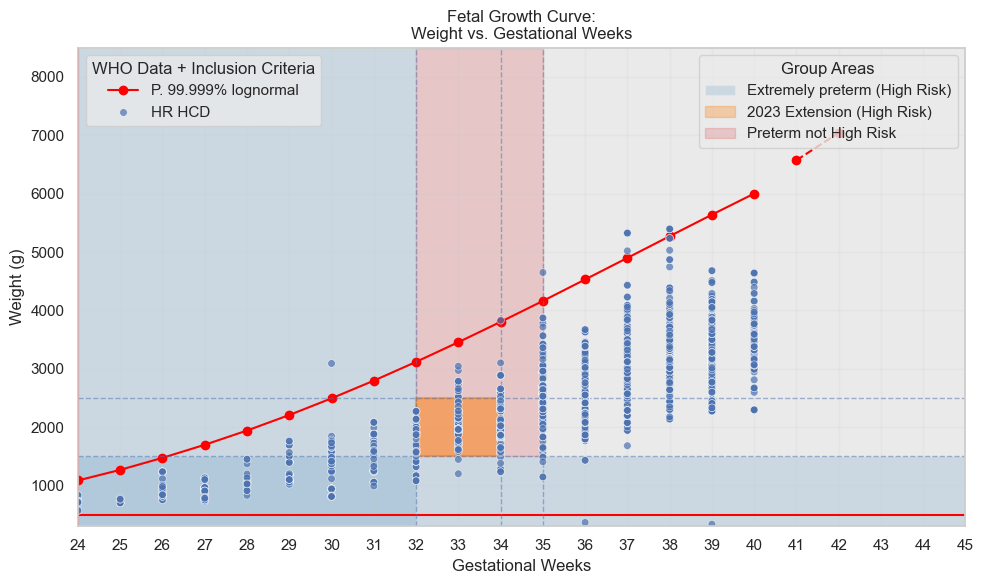

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle, Patch
import seaborn as sns

# === your prep (unchanged) ====================================================
# ... df_oms, predicciones_df, df, etc. as in your code ...

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})
plt.figure(figsize=(10, 6))

# ----- WHO lines (unchanged) -----
plt.axhline(y=501, color='red', linestyle='-')       # PESO = 501 g
plt.axvline(x=24, color='red', linestyle='-')        # SEMANAS = 24

plt.plot(
    df_oms['SEMANAS'],
    df_oms['p_99999_lognormal'],
    color='red', linestyle='-', marker='o',
    label='P. 99.999% lognormal'
)
plt.plot(
    np.array([41, 42]),
    predicciones_df['p_99999_lognormal'],
    color='red', linestyle='--', marker='o'
)

# === NEW: shaded areas for groups =============================================

# axis limits (adjust if you prefer)
x_min, x_max = 24, 45      # gestational age (weeks)
y_min, y_max = 300, 8500   # weight (g); widen if needed

# Extremely preterm (High Risk): GA < 32 OR Weight < 1500
#   -> a left vertical strip + a bottom horizontal strip
extreme_strip = Rectangle((x_min, y_min), 32 - x_min, y_max - y_min,
                          facecolor='tab:blue', alpha=0.15, zorder=0)
extreme_bottom = Rectangle((x_min, y_min), x_max - x_min, 1500 - y_min,
                           facecolor='tab:blue', alpha=0.15, zorder=0)
plt.gca().add_patch(extreme_strip)
plt.gca().add_patch(extreme_bottom)

# 2023 Extension (High Risk): 32–34 w AND 1500–2500 g
extension_rect = Rectangle((32, 1500), 34 - 32, 2500 - 1500,
                           facecolor='tab:orange', alpha=0.30,
                           edgecolor='tab:orange', linewidth=1.5, zorder=1)
plt.gca().add_patch(extension_rect)

# Preterm not High Risk: 32–35 w AND ≥1500 g, EXCLUDING extension
#   -> draw the red block first, then the orange extension on top
pnhr_rect = Rectangle((32, 1500), 35 - 32, y_max - 1500,
                      facecolor='tab:red', alpha=0.18,
                      edgecolor='tab:red', linewidth=1.0, zorder=0.5)
plt.gca().add_patch(pnhr_rect)

# re-add the extension so it sits on top of the red region (shows “exclusion”)
plt.gca().add_patch(extension_rect)

# guide lines
for x in [32, 34, 35]:
    plt.axvline(x, linestyle='--', linewidth=1, alpha=0.5)
for y in [1500, 2500]:
    plt.axhline(y, linestyle='--', linewidth=1, alpha=0.5)

# === your scatter (unchanged) =================================================

df_plot = df.copy()

df_plot['criterio'] = np.select(
    [
        df_plot['RUN'].isin(lista_ruts_cardio),
     #   (df['PESO'] < 1500) & (df_plot['SEMANAS'] > 35),
     #   (df_plot['SEMANAS'] <= 35) & (df_plot['PESO'] < 1500),
     #   (df_plot['SEMANAS'] <= 35) & (df_plot['PESO'] >= 1500)
        
    ],
    [
        'HR HCD',
        #'HR low weigth',
        #'HR low weigth and preterm',
        #'HR preterm'
    ],
    default='otro'
)

sns.scatterplot(
    x='SEMANAS', y='PESO', data=df_plot[df_plot['RUN'].isin(lista_ruts_cardio)],
    hue='criterio', s=30, alpha=0.7, zorder=2
)

# === axes, ticks, legend ======================================================
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel('Gestational Weeks')
plt.ylabel('Weight (g)')     # <- units look like grams
plt.title('Fetal Growth Curve:\nWeight vs. Gestational Weeks')

# force x ticks every 5
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

# legend: combine your scatter legend with area legend
area_handles = [
    Patch(facecolor='tab:blue',  alpha=0.15, label='Extremely preterm (High Risk)'),
    Patch(facecolor='tab:orange', alpha=0.30, edgecolor='tab:orange', label='2023 Extension (High Risk)'),
    Patch(facecolor='tab:red',   alpha=0.18, edgecolor='tab:red',   label='Preterm not High Risk'),
]
# place a second legend for areas; keep seaborn's for points
first_legend = plt.legend(title='WHO Data + Inclusion Criteria', loc='upper left')
plt.gca().add_artist(first_legend)
plt.legend(handles=area_handles, loc='upper right', title='Group Areas')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

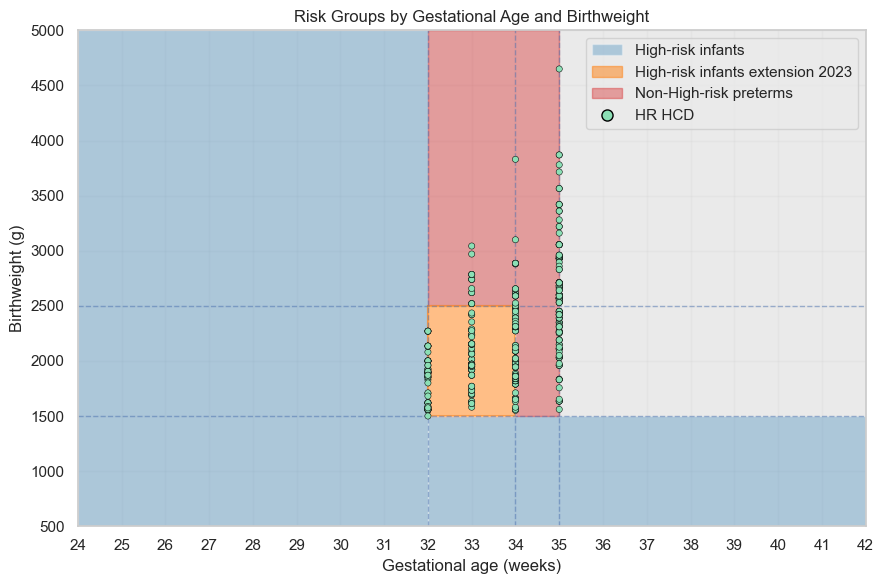

In [48]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import matplotlib.ticker as ticker

# -----------------------------
# Axes ranges (edit if needed)
# -----------------------------
x_min, x_max = 24, 42     # gestational age in weeks
y_min, y_max = 500, 5000    # birthweight in grams

fig, ax = plt.subplots(figsize=(9, 6))

# ---------------------------------------------------------
# Extremely preterm (High Risk): GA < 32  OR  Weight < 1500
# ---------------------------------------------------------
# Left vertical strip: GA < 32
extreme_strip = Rectangle(
    (x_min, y_min),                 # (x, y) bottom-left
    32 - x_min,                     # width
    y_max - y_min,                  # height
    facecolor='tab:blue', alpha=0.30, edgecolor=None
)
ax.add_patch(extreme_strip)

# Bottom horizontal strip: Weight < 1500
extreme_bottom = Rectangle(
    (32, y_min),              # <-- antes: (x_min, y_min)
    x_max - 32,               # <-- antes: x_max - x_min
    1500 - y_min,
    facecolor='tab:blue', alpha=0.30, edgecolor=None
)
ax.add_patch(extreme_bottom)

# ---------------------------------------------------------
# 2023 Extension (High Risk): 32–34 w  AND  1500–2500 g
# ---------------------------------------------------------
extension_rect = Rectangle(
    (32, 1500),
    34 - 32,
    2500 - 1500,
    facecolor='tab:orange', alpha=0.50, edgecolor='tab:orange', linewidth=1.5
)
ax.add_patch(extension_rect)


# ------------------------------------------------------------------
# Preterm not High Risk: 32–35 w  AND  >=1500 g,  EXCLUDING Extension
# ------------------------------------------------------------------
pnhr_rect = Rectangle(
    (32, 1500),
    35 - 32,
    y_max - 1500,
    facecolor='tab:red', alpha=0.40, edgecolor='tab:red', linewidth=1.0
)
ax.add_patch(pnhr_rect)

# Cut out the extension region from the red area for visual clarity
cutout = Rectangle((32, 1500), 34 - 32, 2500 - 1500, facecolor='white', alpha=1.0, edgecolor=None)
ax.add_patch(cutout)
# Re-draw the extension rectangle so its border remains visible
ax.add_patch(extension_rect)

# -----------------------------
# Reference guide lines & text
# -----------------------------
for x in [32, 34, 35]:
    ax.axvline(x, linestyle='--', linewidth=1, alpha=0.5)
for y in [1500, 2500]:
    ax.axhline(y, linestyle='--', linewidth=1, alpha=0.5)

sns.scatterplot(
    x='SEMANAS', y='PESO',
    data=df_plot[df_plot['RUN'].isin(lista_ruts_cardio)].query('(35>=SEMANAS>=32) & (PESO>=1500)'),
    hue='criterio', s=20, alpha=1, zorder=3, edgecolor='black',
    palette = {'HR HCD': "#8bdfb5",'otro': '#228B22'}
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Gestational age (weeks)")
ax.set_ylabel("Birthweight (g)")
ax.set_title("Risk Groups by Gestational Age and Birthweight")
ax.grid(True, alpha=0.2)

# 👉 Force ticks every 5 weeks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

from matplotlib.lines import Line2D
legend_items = [
    Patch(facecolor='tab:blue',  alpha=0.30, label='High-risk infants'),
    Patch(facecolor='tab:orange', alpha=0.50, edgecolor='tab:orange', label='High-risk infants extension 2023'),
    Patch(facecolor='tab:red', alpha=0.40, edgecolor='tab:red', label='Non-High-risk preterms'),
    Line2D([0], [0], marker='o', color='w', label='HR HCD',
           markerfacecolor='#8bdfb5', markersize=8, markeredgecolor='black', lw=0),
    ]
ax.legend(handles=legend_items, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()
# To save: plt.savefig("risk_groups_ga_weight.png", dpi=300, bbox_inches="tight")

In [ ]:
from scipy.stats import lognorm


# 1) Cargar y filtrar tu DF
df1 = (
    pd.read_csv(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv',
                encoding="latin-1", sep=";")
      .dropna(subset=['PESO','SEMANAS'])
     # .query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))')
     # .query('VIVO == "SI"')
)

# 2) Para cada semana: ajustar y calcular quantiles 0.5% y 99.5%
weeks = np.sort(df1['SEMANAS'].unique())
lower_q = []
upper_q = []

for wk in weeks:
    datos = df1.loc[df1['SEMANAS']==wk, 'PESO']
    # forzar loc=0 para verdadera log-normal
    shape, loc, scale = lognorm.fit(datos.values, floc=0)
    lower_q.append(lognorm.ppf(0.005, shape, loc=loc, scale=scale))
    upper_q.append(lognorm.ppf(0.995, shape, loc=loc, scale=scale))

# 3) Identificar outliers que queden fuera de esos límites
df1['outlier'] = (
    (df1['PESO'] < df1['SEMANAS'].map(dict(zip(weeks, lower_q)))) |
    (df1['PESO'] > df1['SEMANAS'].map(dict(zip(weeks, upper_q))))
)

# 4) Graficar
plt.figure(figsize=(14, 10))

# scatter de todo el df1, grises los normales y rojos los outliers
plt.scatter(df1.loc[~df1['outlier'], 'SEMANAS'],
            df1.loc[~df1['outlier'], 'PESO'],
            alpha=0.3, s=20, label='Dentro 99 % central')
plt.scatter(df1.loc[df1['outlier'], 'SEMANAS'],
            df1.loc[df1['outlier'], 'PESO'],
            color='red', alpha=0.6, s=30, label='Fuera de 99 %')

# las dos curvas de corte
plt.plot(weeks, upper_q, color='black', linewidth=2, label='Percentil 99.5%')
plt.plot(weeks, lower_q, color='black', linewidth=2, label='Percentil 0.5%')

plt.xlabel('Semana gestacional')
plt.ylabel('Peso al nacer')
plt.title('Curvas de corte log-normal por semana (99 % central)')
plt.ylim(0, max(upper_q)*1.05)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Projections for weeks 41 to 45:
    p_00001_lognormal  p_99999_lognormal
41            2322.53            6573.26
42            2483.37            7043.87


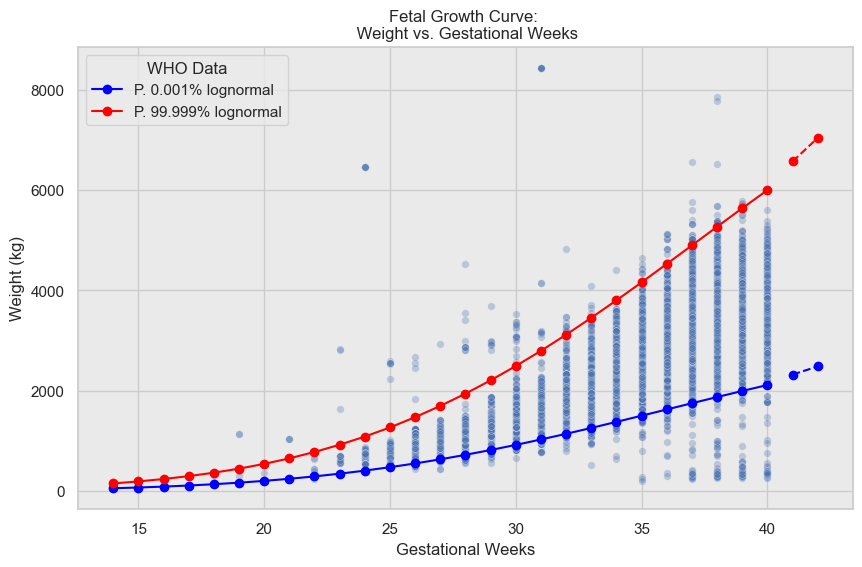

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_oms tiene una columna llamada 'SEMANAS' y columnas con los percentiles calculados
semanas = df_oms['SEMANAS'].values
pred_semanas = np.array([41, 42])

# Lista de los percentiles a proyectar
percentiles = ['p_00001_lognormal', 'p_99999_lognormal']

# Diccionario para almacenar las predicciones
predicciones = {}

# Realizar el ajuste de un polinomio de grado 2 para cada percentil
for percentil in percentiles:
    coefs = np.polyfit(semanas, df_oms[percentil].values, 2)
    poly_func = np.poly1d(coefs)
    predicciones[percentil] = poly_func(pred_semanas)

# Convertir predicciones a un DataFrame
predicciones_df = pd.DataFrame(predicciones, index=pred_semanas)

print("Projections for weeks 41 to 45:")
print(predicciones_df)

# Crear la figura y ejes
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#EAEAEA"})
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar datos históricos y proyecciones
ax.plot(
    df_oms['SEMANAS'], df_oms['p_00001_lognormal'], 
    color='blue', linestyle='-', marker='o', label='P. 0.001% lognormal'
)
ax.plot(
    pred_semanas, predicciones_df['p_00001_lognormal'], 
    color='blue', linestyle='--', marker='o'
)

ax.plot(
    df_oms['SEMANAS'], df_oms['p_99999_lognormal'], 
    color='red', linestyle='-', marker='o', label='P. 99.999% lognormal'
)
ax.plot(
    pred_semanas, predicciones_df['p_99999_lognormal'], 
    color='red', linestyle='--', marker='o'
)

sns.scatterplot(
    x='SEMANAS', y='PESO', data=df, s=30, alpha=0.3, ax=ax  # Scatterplot sobre `ax`
)

# Configuración del gráfico
ax.set_title('Fetal Growth Curve: \n Weight vs. Gestational Weeks')
ax.set_xlabel('Gestational Weeks')
ax.set_ylabel('Weight (kg)')
ax.legend(title='WHO Data')
ax.grid(True)

# Guardar la imagen con 400 dpi y en EPS
# fig.savefig("/Users/ignasi/Documents/ISCI/Projects/nirsevimab/Image/OMS_weight.png", dpi=400)  
# fig.savefig("/Users/ignasi/Documents/ISCI/Projects/nirsevimab/Image/OMS_weight.eps", format="eps")  

# Mostrar la figura
plt.show()


In [24]:
# Hacer un merge entre df y df_oms basado en la columna 'SEMANAS'
merged_df = pd.merge((
                    df
                    .dropna(subset=['SEMANAS'])  # Eliminar filas con NaN en 'SEMANAS'
                    .assign(SEMANAS=lambda x: x['SEMANAS'].astype(int))  # Convertir 'SEMANAS' a int
                    )
                    , df_oms[['SEMANAS', 'p_00001', 'p_99999']],
                    on='SEMANAS', 
                    how='inner'
                    )

# Filtrar los valores de 'PESO' que están entre los percentiles 1 y 99
filtered_df = merged_df[(merged_df['PESO'] >= merged_df['p_00001']) & (merged_df['PESO'] <= merged_df['p_99999'])]

# Contar cuántos valores cumplen con la condición
count_filtered_values = filtered_df.shape[0]
# Calcular el total de elementos que cumplen con la condición
total_n = len(df.dropna(subset=['SEMANAS']).query("SEMANAS <= 40"))

KeyError: 'p_00001'

In [25]:
print(f"Delete data over 42 weeks: {len(df.dropna(subset=['SEMANAS']).query('SEMANAS > 42'))}")

Delete data over 42 weeks: 0


In [26]:
# Imprimir el tamaño inicial del DataFrame
print(f"Initial dataframe: {len(df)}")

# Imprimir el número de datos eliminados con más de 40 semanas
print(f"Delete data over 40 weeks: {len(df.dropna(subset=['SEMANAS']).query('SEMANAS > 40'))}")

# Imprimir el total de valores, los valores filtrados y los no en el percentil
print(f"Total n: {total_n} \nCount filtered by percentil: {count_filtered_values} \nNot in the percentile: {total_n - count_filtered_values}")

# Calcular el porcentaje de datos que se mantienen
percentage = filtered_df.shape[0] / len(df.dropna(subset=['SEMANAS']).query('SEMANAS <= 40'))

# Imprimir el porcentaje de datos que se mantienen
print(f"Data we keep: {percentage:.3%}")


Initial dataframe: 151905
Delete data over 40 weeks: 0


NameError: name 'total_n' is not defined

In [42]:
filtered_df.shape[0] , len(df.dropna(subset=['SEMANAS']).query('SEMANAS <= 40'))

(14275, 14703)

In [31]:
filtered_df.query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))').shape[0] / df.dropna(subset=['SEMANAS']).query('((PESO<1500) | (SEMANAS<=35) | (RUN.isin(@lista_ruts_cardio)))').shape[0]

0.9695714188684371

In [21]:
df_curvas

,SEMANAS,p_025,p_050,p_100,p_250,p_500,p_750,p_900,p_950,p_975
0,16.0,200.00,200.00,200.0,200.00,200.0,200.00,200.0,200.00,200.00
1,18.0,298.00,298.00,298.0,298.00,298.0,298.00,298.0,298.00,298.00
2,19.0,311.68,318.35,331.7,371.75,769.5,1145.00,1145.0,1145.00,1145.00
3,20.0,355.00,355.00,355.0,355.00,355.0,355.00,355.0,355.00,355.00
4,21.0,1040.00,1040.00,1040.0,1040.00,1040.0,1040.00,1040.0,1040.00,1040.00
5,22.0,254.38,273.75,312.5,400.00,435.0,582.50,645.0,652.50,656.25
6,23.0,559.00,559.00,559.0,567.25,670.0,700.00,2225.0,2825.00,2832.50
7,24.0,544.00,544.00,557.0,674.00,715.0,750.00,830.0,5336.20,6453.00
8,25.0,577.25,615.00,650.0,700.00,795.0,882.00,977.0,1624.00,2550.00
9,26.0,500.00,591.00,649.0,800.00,885.0,980.00,1152.0,1230.00,1235.00


In [13]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from scipy.stats import ks_2samp
import warnings
from preproces_prod3 import *
from matching_case_control import *

warnings.filterwarnings("ignore")

import pickle

with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)

#df_vrs_match_case, _ = call_data('NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv')
df_pf = (
        pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv')
        # Drop de columnas según nombre
        .pipe(lambda df: df.drop(columns=[
            col for col in df.columns
            if (
                col.startswith('inm_') or
                col.startswith('MES_') or
                col.startswith('DIA_') or
                col.startswith('SERC_') or
                (col.startswith('ANO_') and col.endswith('TRAS')) or
                col.startswith('AREAF') or
                col.startswith('dias_en') or
                col.startswith('fecha_tras') or
                col.endswith('Dall')
            )
        ]))

        .pipe(lambda df: df.assign(
            region=df.region.where(df.RUN != 'ac483764636448d753930868dd3192a785e3728a2d81b3fc44dba45c3506255a', 'METROPOLITANA')
        ))
        .pipe(lambda df: df.assign(
            region=df.region.where(df.COMUNA != 12202, 'MAGALLANES Y ANTARTICA')
        ))

        .assign(
            cardio1=lambda x: x.RUN.isin(lista_ruts_cardio).astype(int),
            log_peso=lambda x: np.log(x.PESO),
          #  Macrozones = lambda x: x.region.map(region_to_macrozone_agencia).replace(leo_zonas_rename),
            super_preterm = lambda x: ((x.SEMANAS<32) | (x.PESO<1500)).astype(int),
        )
        .copy()
    )

df_pf_sd = (
    df_pf
    .copy()
    .assign(fechaIng_any_modify = lambda x: x.fechaIng_any,
                        fechaIng_vrs_modify = lambda x: x.fechaIng_vrs,
                        fecha_def = lambda x: pd.to_datetime(x['FECHA_DEFUNCION'], format='%d%b%Y'),
                        muerto_pre_campain = lambda x: x.fecha_def < pd.to_datetime("2024-04-01"),
                        muerto_7days_birth = lambda x: x.fecha_def <= x.fecha_nac + pd.DateOffset(days=7))
    # .query('muerto_pre_campain==False') 
    # .query('muerto_7days_birth==False')
    #.sort_values(by='fechaIng_vrs').drop_duplicates(subset=['RUN'], keep='first')
    #.query('VIVO=="SI"')
    .query('((SEMANAS<32) | (PESO<1500) | (RUN.isin(@lista_ruts_cardio))) | ((32<=SEMANAS<=34) & (PESO>2500)) | ((PESO>=1500) & (SEMANAS==35)) & ~(RUN.isin(@lista_ruts_cardio))')
    )


df_pf_sd.loc[df_pf_sd.fechaIng_any_modify <= df_pf_sd.fecha_nac + pd.DateOffset(days=7), ['fechaIng_any_modify','fechaIng_vrs_modify','fecha_upc_vrs','fechaIng_LRTI']] = pd.NaT


n_rows_inicial= 157557
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 157557


In [14]:
df_pf_sd_safe = df_pf_sd.copy()

In [119]:
df_pf_sd = df_pf_sd_safe.copy()

In [120]:

filters = {
    # 'G.a.w > 42': (df_pf_sd.SEMANAS > 42),
    # 'G.a.w < 24': (df_pf_sd.SEMANAS < 24),
    # 'G.weight <=  p_l': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal),
    # 'G.weight >= p_u': (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
    'death_at_born': df_pf_sd.RUN.isin(df_pf_sd[(df_pf_sd['VIVO']=="NO") & (df_pf_sd['muerto_7days_birth'])].RUN.unique()),
    'curve_peso_edadGest': df_pf_sd.RUN.isin((df_pf_sd[(df_pf_sd['SEMANAS']<24) | (df_pf_sd['SEMANAS']>42) | (df_pf_sd['PESO'] <= 500) | (df_pf_sd['PESO'] > df_pf_sd['p_99999_lognormal'])].RUN.unique())),#(df_pf_sd['SEMANAS']>=24) & (df_pf_sd['SEMANAS']<=42) & (df_pf_sd['PESO'] > 500) & (df_pf_sd['PESO'] <= df_pf_sd['p_99999_lognormal'])  ((df_pf_sd.PESO < df_pf_sd.p_00001_lognormal) | (df_pf_sd.PESO > df_pf_sd.p_99999_lognormal) | (df_pf_sd.SEMANAS > 42) | (df_pf_sd.SEMANAS < 24)),
    'Intersex': df_pf_sd.RUN.isin(df_pf_sd[(df_pf_sd.SEXO == 9)].RUN.unique()),
#   'Unidentifiable ID': (df_pf_sd.MARCA==1),
#   'Mom age': ((df_pf_sd.EDAD_M > 51) | (df_pf_sd.EDAD_M < 12)),
#   'vrs_7_days_birth': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any >= df_pf_sd.fecha_nac].RUN.unique())) & (df_pf_sd.RUN.isin(df_pf_sd[(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7))].RUN.unique())), #(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7)), #
    'Inconsistent dates': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac].RUN.unique())) & (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any.notna() & df_pf_sd.fecha_nac.notna()].RUN.unique())), #
    'VRS Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_vrs_modify < pd.to_datetime("2024-04-01")].RUN.unique())),
}

all_ruts_filtred = {}

# Crear la tabla vacía con los nombres de los filtros
filter_names = list(filters.keys())
intersection_table = pd.DataFrame(index=filter_names, columns=filter_names + ['Total'])

df_diagonal = {}


# Rellenar la tabla con las intersecciones
for f1 in filter_names:
    for f2 in filter_names:
        if f1 == f2:
            super_filter = filters[f1]
            for f3 in filter_names:
                if f3 == f1:
                    continue
                else:
                    super_filter = super_filter & (~filters[f3])
                    
                
            count = df_pf_sd[super_filter].RUN.nunique() #len(df_pf_sd[super_filter])
            all_ruts_filtred[f'just_{f1}'] = df_pf_sd[super_filter].RUN.unique()
            df_diagonal[f1] = count
        else:
            # Intersección: cuántos datos elimina al aplicar f1 y f2 simultáneamente
            combined_filter = filters[f1] & filters[f2]
            all_ruts_filtred[f'{f1}_and_{f2}'] = df_pf_sd[combined_filter].RUN.unique()
            count = df_pf_sd[combined_filter].RUN.nunique() #len(df_pf_sd[combined_filter])
        
        intersection_table.loc[f1, f2] = count

    # Calcular el total general (datos eliminados al aplicar f1 sin exclusividad)
    intersection_table.loc[f1, 'Total'] = df_pf_sd[filters[f1]].RUN.nunique() - intersection_table.loc[f1, f1]  #len(df_pf_sd[filters[f1]])


for fname, cond in filters.items():
    df_pf_sd[fname] = cond  # Esto creará o sobrescribirá la columna con valores True/False

filter_names = list(filters.keys())

ruts_filts = df_pf_sd.assign(num_filters_cumplidos = lambda x: x[filter_names].sum(axis=1)).groupby('RUN',as_index=False).agg({'num_filters_cumplidos': 'max'})

df_pf_sd = df_pf_sd.merge(ruts_filts, on='RUN', how='left')


In [94]:
intersection_table

,death_at_born,curve_peso_edadGest,Intersex,Inconsistent dates,VRS Hospitalization date before start of campaign,Total
death_at_born,226,202,3,0,0,203
curve_peso_edadGest,202,234,2,0,1,203
Intersex,3,2,1,0,0,3
Inconsistent dates,0,0,0,4,0,0
VRS Hospitalization date before start of campaign,0,1,0,0,15,1


In [75]:
# 3) Construir la tabla de intersecciones para “3 o más” filtros
intersection_table_3plus = pd.DataFrame(
    index=filter_names,
    columns=filter_names + ['Total']
)

for f1 in filter_names:

    intersection_table_3plus.loc[f1, 'Total'] = df_pf_sd[df_pf_sd[f1] & (df_pf_sd['num_filters_cumplidos'] == 3)].RUN.nunique()
    
    for f2 in filter_names:
        if f1 == f2:
            # Podrías dejar vacío, o poner 0, o un guión
            intersection_table_3plus.loc[f1, f2] = ''
        else:
            # Marcamos “x” si existe AL MENOS un registro que cumple:
            #   f1 == True, f2 == True y num_filters_cumplidos >= 3
            mask_f1_f2_3plus = (
                df_pf_sd[f1] & 
                df_pf_sd[f2] & 
                (df_pf_sd['num_filters_cumplidos'] == 3)
            )
            intersection_table_3plus.loc[f1, f2] = 'x' if df_pf_sd[mask_f1_f2_3plus].RUN.nunique()>=1 else ''
            
df_diagonal_real = pd.DataFrame([df_diagonal])
df_diagonal_real.index = ['Diagonal']
intersection_table_3plus = pd.concat([intersection_table_3plus, df_diagonal_real], ignore_index=False)
intersection_table_3plus

,death_at_born,curve_peso_edadGest,Intersex,Inconsistent dates,VRS Hospitalization date before start of campaign,Total
death_at_born,,x,x,,,2
curve_peso_edadGest,x,,x,,,2
Intersex,x,x,,,,2
Inconsistent dates,,,,,,0
VRS Hospitalization date before start of campaign,,,,,,0
Diagonal,226,234,1,4,15,NaN


In [124]:
Ruts = []

for key in all_ruts_filtred.keys():
    for rut in all_ruts_filtred[key]:
        if rut in Ruts:
            continue
        else:
            Ruts.append(rut)

In [125]:
len(Ruts)

684

In [128]:
df_pf_sd.query('RUN.isin(@Ruts)').drop_duplicates('RUN').query('num_filters_cumplidos>=1').groupby(['take_nirse','event_vrs']).RUN.nunique().unstack() # & (RUN.isin(@Ruts))

event_vrs,False,True
take_nirse,,
False,456,1
True,222,5
